불균형 데이터 문제를 해결하기 위한 대표적인 방법인 **오버샘플링(OverSampling)**과 **언더샘플링(UnderSampling)**

| 방법        | 설명                    | 장점        | 단점                  |사용시기|
| --------- | --------------------- | --------- | ------------------- |---|
| **오버샘플링** | 소수 클래스의 데이터를 인위적으로 늘림 | 데이터 손실 없음 | 과적합(overfitting) 위험 | 소수 클래스의 정보가 중요할 때|
| **언더샘플링** | 다수 클래스의 데이터를 줄임       | 빠른 학습 가능  | 정보 손실 가능            |학습 속도가 중요하거나 데이터가 매우 많을 때|

1. 오버샘플링 (OverSampling)
- 소수 클래스의 데이터를 복제하거나 생성하여 클래스 간 균형을 맞춤
- 대표 기법: RandomOverSampler, SMOTE 등

2. 언더샘플링 (UnderSampling)
- 다수 클래스의 일부 데이터를 제거하여 클래스 간 균형을 맞춤
- 대표 기법: RandomUnderSampler, TomekLinks, NearMiss 등

3. 고급 불균형 처리 기법

| 기법 (Method) | 구분 (Type) | 원리 / 동작 방식 | 장점 | 단점 / 위험요소 |
| --- | --- | --- | --- | --- |
| **SMOTE** | 오버샘플링 | 소수 클래스 데이터를 선형 보간으로 생성 | 과적합 줄임 | 잡음 데이터 생성 가능 |
| **RandomOverSampler** | 오버샘플링 | 소수 클래스를 복제 | 단순, 빠름 | 과적합 위험 |
| **RandomUnderSampler** | 언더샘플링 | 다수 클래스 일부를 무작위 제거 | 빠름 | 정보 손실 위험 |
| **NearMiss** | 언더샘플링 | 소수 클래스 근처의 다수 클래스만 유지 | 경계 샘플 유지 | 과도한 제거 가능 |
| **TomekLinks** | 클렌징 | 클래스 경계선의 모호한 쌍 제거 | 데이터 정제 | 성능 개선 제한적 |

---

**주요 기법별 요약**

* **오버샘플링 (Over-sampling)**: 적은 쪽(소수 클래스)의 데이터를 늘리는 방식입니다.
* **SMOTE**: 기존 데이터를 단순히 복사하는 대신 가상의 데이터를 생성하여 과적합을 방지하지만, 노이즈가 포함될 수 있습니다.
* **RandomOverSampler**: 기존 소수 데이터를 단순 무작위 복제하여 속도가 빠르지만 과적합 위험이 큽니다.


* **언더샘플링 (Under-sampling)**: 많은 쪽(다수 클래스)의 데이터를 줄여 균형을 맞추는 방식입니다.
* **RandomUnderSampler**: 다수 데이터를 무작위로 삭제하여 처리 속도가 빠르나 중요한 정보가 손실될 수 있습니다.
* **NearMiss**: 경계선에 가까운 데이터 위주로 남겨 경계를 명확히 하지만, 너무 많은 데이터가 삭제될 위험이 있습니다.


* **클렌징 (Cleansing)**: 데이터의 경계면을 정리하여 노이즈를 제거하는 방식입니다.
* **TomekLinks**: 경계선 부근에 인접한 서로 다른 클래스 쌍을 찾아 제거하여 경계를 정제하지만, 단독 사용 시 전체적인 불균형 해소 효과(성능 개선)는 제한적입니다.




# 1. 데이터 준비

make_classification()의 파라미터

| 파라미터                     | 설명                                |
| ------------------------ | --------------------------------- |
| `n_samples=1000`         | 총 샘플 수: 데이터 1000개 생성              |
| `n_features=2`           | 총 특성 수: 2개의 특성(피처)을 가짐            |
| `n_informative=2`        | **예측에 실제로 유용한(의미 있는)** 특성 수: 2개   |
| `n_redundant=0`          | **다른 특성에서 파생된 중복 특성** 수: 없음       |
| `n_clusters_per_class=1` | 클래스당 클러스터 수: 각 클래스가 1개의 클러스터로 구성  |
| `weights=[0.9, 0.1]`     | 각 클래스의 비율: 클래스 0이 90%, 클래스 1이 10% |
| `flip_y=0`               | 레이블을 무작위로 바꿀 확률: 노이즈 없음           |
| `random_state=42`        | 난수 시드: 결과 재현 가능하게 설정              |


In [ ]:
from sklearn.datasets import make_classification
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
import platform
import sklearn

print(platform.system())
if platform.system()== 'Windows':
   sklearn.set_config(display='text')

In [ ]:
import matplotlib.pyplot as plt

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family ='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family ='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family ='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

In [ ]:


# 불균형 이진 분류 데이터 생성
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1,
                           weights=[0.9, 0.1], flip_y=0, random_state=42)

print("Original class distribution:", Counter(y))
print(X.shape, y.shape)
print(pd.Series(y).value_counts())

Original class distribution: Counter({np.int64(0): 900, np.int64(1): 100})
(1000, 2) (1000,)
0    900
1    100
Name: count, dtype: int64


# 2. 고급 불균형 처리 기법 예제

## 1. SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("SMOTE 후:", Counter(y_smote))


SMOTE 후: Counter({np.int64(0): 900, np.int64(1): 900})


## 2. RandomOverSampler

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X, y)

print("RandomOverSampler 후:", Counter(y_ros))


RandomOverSampler 후: Counter({np.int64(0): 900, np.int64(1): 900})


## 3. RandomUnderSampler

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

print("RandomUnderSampler 후:", Counter(y_rus))


RandomUnderSampler 후: Counter({np.int64(0): 100, np.int64(1): 100})


## 4. NearMiss

In [ ]:
from imblearn.under_sampling import NearMiss

nm = NearMiss(version=1)
X_nm, y_nm = nm.fit_resample(X, y)

print("NearMiss 후:", Counter(y_nm))


NearMiss 후: Counter({np.int64(0): 100, np.int64(1): 100})


## 5. TomekLinks

In [ ]:
from imblearn.under_sampling import TomekLinks

tl = TomekLinks()
X_tl, y_tl = tl.fit_resample(X, y)

print("TomekLinks 후:", Counter(y_tl))



TomekLinks 후: Counter({np.int64(0): 896, np.int64(1): 100})


# 3. 시각화 함수


In [ ]:
def plot_resampled(X, y, title):
    plt.figure(figsize=(4, 3))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=30)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)


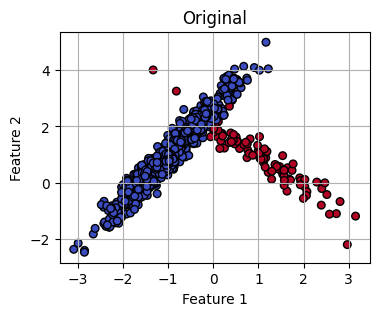

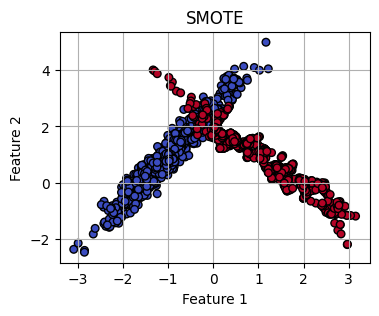

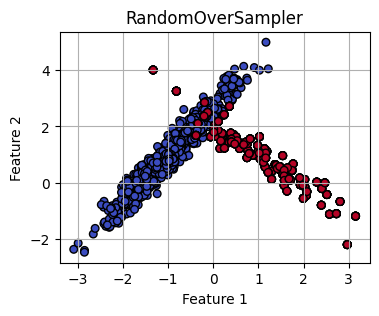

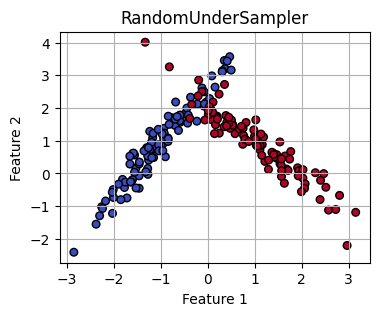

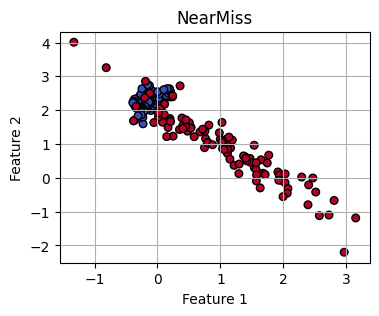

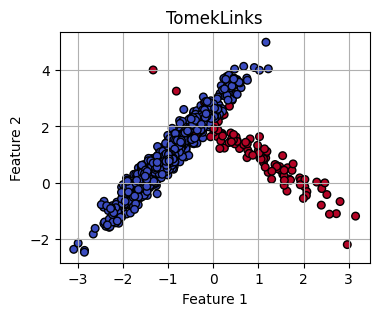

In [ ]:
# 시각화 실행
plot_resampled(X, y, "Original")
plot_resampled(X_smote, y_smote, "SMOTE")
plot_resampled(X_ros, y_ros, "RandomOverSampler")
plot_resampled(X_rus, y_rus, "RandomUnderSampler")
plot_resampled(X_nm, y_nm, "NearMiss")
plot_resampled(X_tl, y_tl, "TomekLinks")

plt.show()


## 4. 각 샘플링 기법과 모델을 Pipeline으로 연결

In [ ]:
'''
Scikit-learn의 기본 Pipeline은 중간 단계(step)는 반드시 fit과 transform을 구현한 transformer여야 한다.
하지만 SMOTE, RandomOverSampler, NearMiss 등은 Scikit-learn이 아닌 imblearn 라이브러리의 transformer로, scikit-learn의 기본 Pipeline에서 직접 사용하면 오류가 발생한다.
'''
from imblearn.pipeline import Pipeline  # 중요
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import numpy as np

def evaluate_pipeline_grid(sampler, model, model_name, param_grid):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('sampler', sampler),
        ('classifier', model)
    ])

    # GridSearchCV 적용
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1',
        cv=5,
        n_jobs=-1
    )

    grid.fit(X, y)

    return {
        "model": model_name,
        "sampler": sampler.__class__.__name__,
        "best_f1": np.round(grid.best_score_, 4),
        "best_params": grid.best_params_
    }


## 5. 조합평가

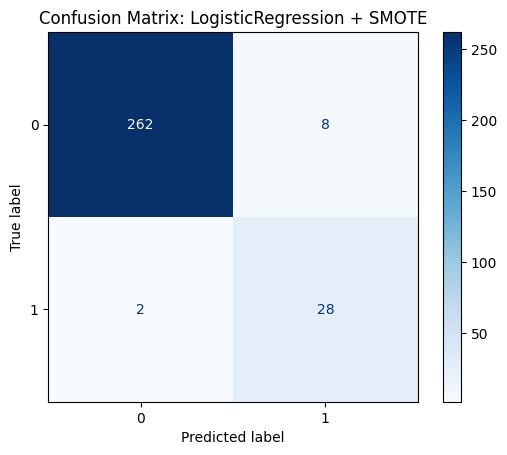

Classification Report: LogisticRegression + SMOTE
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       270
           1       0.78      0.93      0.85        30

    accuracy                           0.97       300
   macro avg       0.89      0.95      0.91       300
weighted avg       0.97      0.97      0.97       300



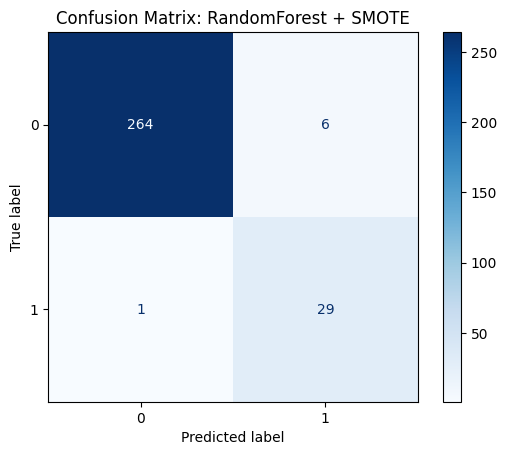

Classification Report: RandomForest + SMOTE
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       270
           1       0.83      0.97      0.89        30

    accuracy                           0.98       300
   macro avg       0.91      0.97      0.94       300
weighted avg       0.98      0.98      0.98       300



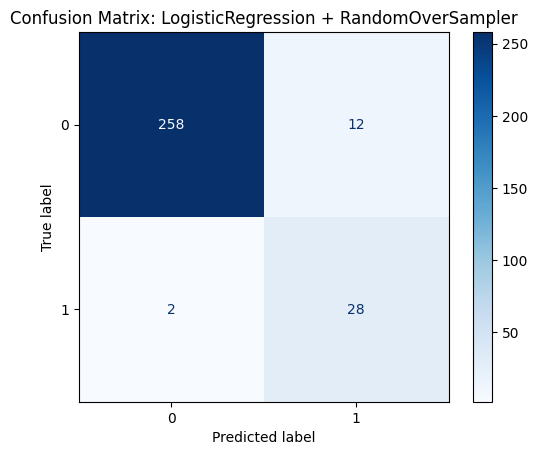

Classification Report: LogisticRegression + RandomOverSampler
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       270
           1       0.70      0.93      0.80        30

    accuracy                           0.95       300
   macro avg       0.85      0.94      0.89       300
weighted avg       0.96      0.95      0.96       300



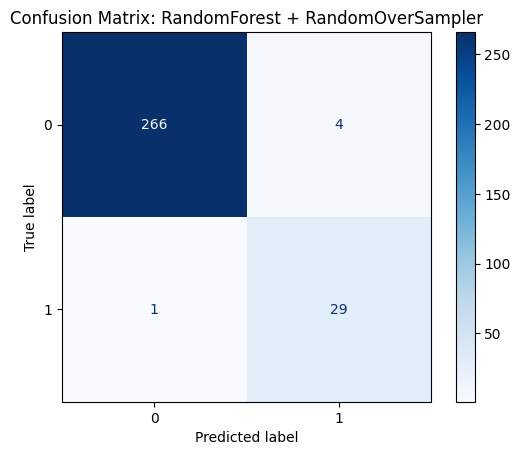

Classification Report: RandomForest + RandomOverSampler
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       270
           1       0.88      0.97      0.92        30

    accuracy                           0.98       300
   macro avg       0.94      0.98      0.96       300
weighted avg       0.98      0.98      0.98       300



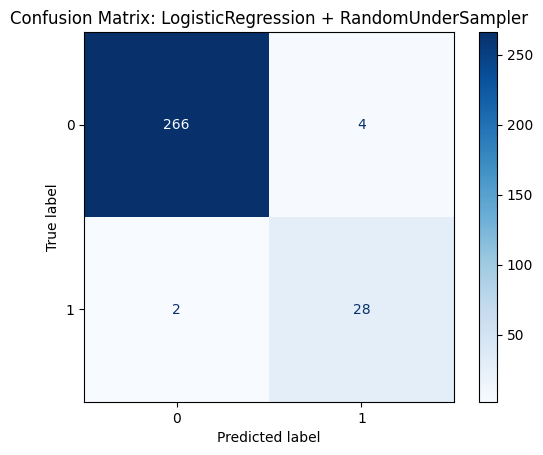

Classification Report: LogisticRegression + RandomUnderSampler
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       270
           1       0.88      0.93      0.90        30

    accuracy                           0.98       300
   macro avg       0.93      0.96      0.95       300
weighted avg       0.98      0.98      0.98       300



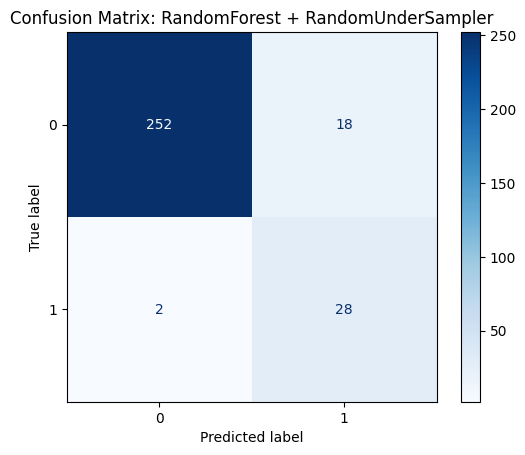

Classification Report: RandomForest + RandomUnderSampler
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       270
           1       0.61      0.93      0.74        30

    accuracy                           0.93       300
   macro avg       0.80      0.93      0.85       300
weighted avg       0.95      0.93      0.94       300



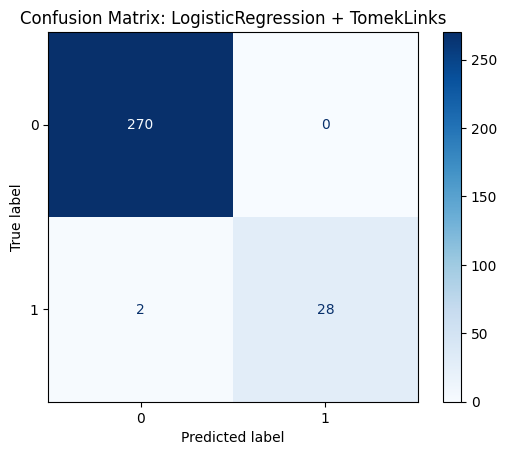

Classification Report: LogisticRegression + TomekLinks
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       270
           1       1.00      0.93      0.97        30

    accuracy                           0.99       300
   macro avg       1.00      0.97      0.98       300
weighted avg       0.99      0.99      0.99       300



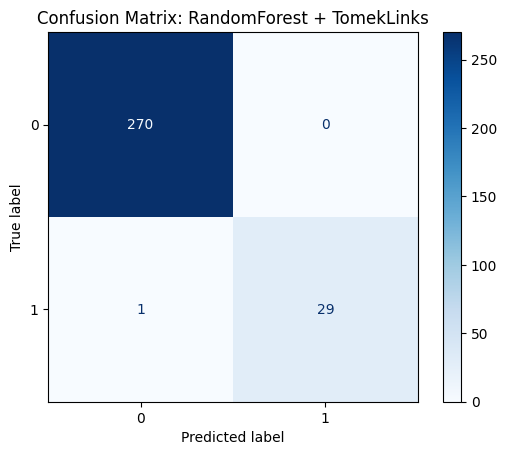

Classification Report: RandomForest + TomekLinks
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       270
           1       1.00      0.97      0.98        30

    accuracy                           1.00       300
   macro avg       1.00      0.98      0.99       300
weighted avg       1.00      1.00      1.00       300



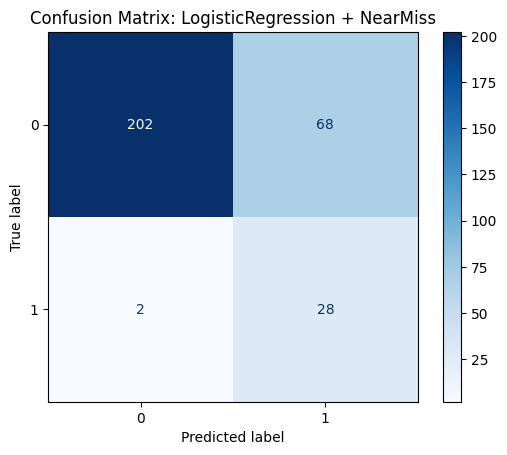

Classification Report: LogisticRegression + NearMiss
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       270
           1       0.29      0.93      0.44        30

    accuracy                           0.77       300
   macro avg       0.64      0.84      0.65       300
weighted avg       0.92      0.77      0.81       300



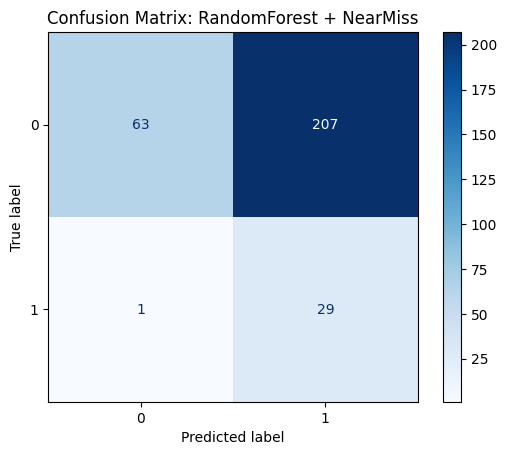

Classification Report: RandomForest + NearMiss
              precision    recall  f1-score   support

           0       0.98      0.23      0.38       270
           1       0.12      0.97      0.22        30

    accuracy                           0.31       300
   macro avg       0.55      0.60      0.30       300
weighted avg       0.90      0.31      0.36       300

{'model': 'RandomForest', 'sampler': 'NearMiss', 'best_f1': np.float64(0.3102), 'best_params': {'classifier__max_depth': None, 'classifier__n_estimators': 100}}


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

samplers = [
    SMOTE(random_state=42),
    RandomOverSampler(random_state=42),
    RandomUnderSampler(random_state=42),
    TomekLinks(),
    NearMiss()
]

models_with_params = [
    (
        LogisticRegression(solver='liblinear'),
        "LogisticRegression",
        {
            'classifier__C': [0.1, 1, 10]
        }
    ),
    (
        RandomForestClassifier(random_state=42),
        "RandomForest",
        {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [3, 5, None]
        }
    )
]

results = []

for sampler in samplers:
    for model, model_name, param_grid in models_with_params:
        try:
            result = evaluate_pipeline_grid(sampler, model, model_name, param_grid)
            results.append(result)
        except Exception as e:
            print(f" Error with {model_name} + {sampler.__class__.__name__}: {e}")

print(result)

## 6. 시각화

                model             sampler  best_f1  \
0  LogisticRegression               SMOTE   0.7984   
1        RandomForest               SMOTE   0.8538   
2  LogisticRegression   RandomOverSampler   0.7735   
3        RandomForest   RandomOverSampler   0.9087   
4  LogisticRegression  RandomUnderSampler   0.7850   
5        RandomForest  RandomUnderSampler   0.7501   
6  LogisticRegression          TomekLinks   0.8811   
7        RandomForest          TomekLinks   0.9304   
8  LogisticRegression            NearMiss   0.5199   
9        RandomForest            NearMiss   0.3102   

                                         best_params  
0                               {'classifier__C': 1}  
1  {'classifier__max_depth': None, 'classifier__n...  
2                              {'classifier__C': 10}  
3  {'classifier__max_depth': None, 'classifier__n...  
4                              {'classifier__C': 10}  
5  {'classifier__max_depth': 5, 'classifier__n_es...  
6                   

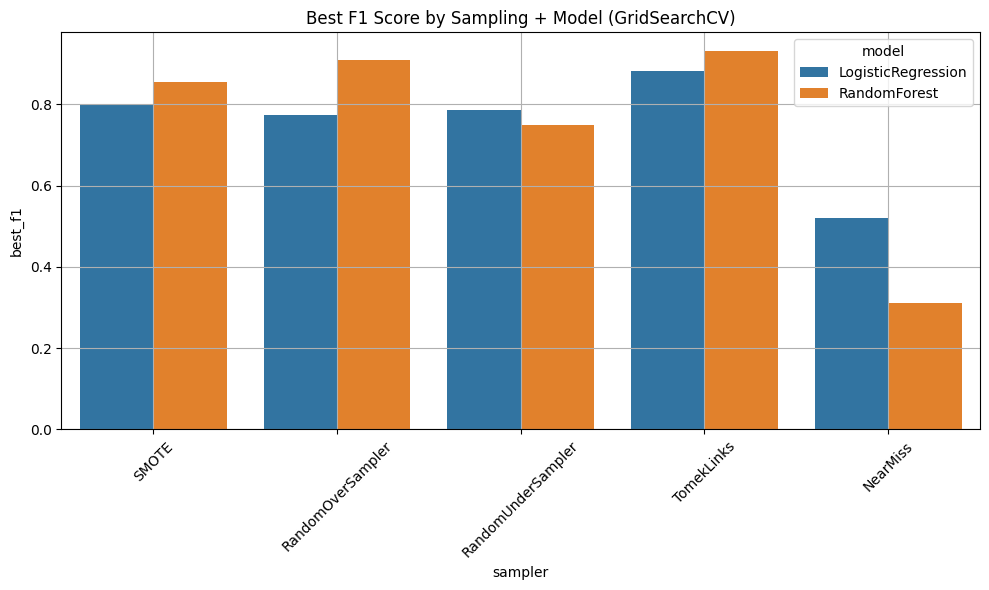

In [ ]:
import pandas as pd
import seaborn as sns

df_result = pd.DataFrame(results)
print(df_result)


# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=df_result, x='sampler', y='best_f1', hue='model')
plt.title("Best F1 Score by Sampling + Model (GridSearchCV)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


7. 통합 전체소스

클래스 분포: Counter({np.int64(0): 900, np.int64(1): 100})
                model             sampler  best_f1  \
0  LogisticRegression               SMOTE   0.8578   
1        RandomForest               SMOTE   0.9347   
2  LogisticRegression   RandomOverSampler   0.7668   
3        RandomForest   RandomOverSampler   0.9265   
4  LogisticRegression  RandomUnderSampler   0.7603   
5        RandomForest  RandomUnderSampler   0.7196   
6  LogisticRegression          TomekLinks   0.8911   
7        RandomForest          TomekLinks   0.9354   
8  LogisticRegression            NearMiss   0.7565   
9        RandomForest            NearMiss   0.2105   

                                         best_params  
0                               {'classifier__C': 1}  
1  {'classifier__max_depth': 3, 'classifier__n_es...  
2                              {'classifier__C': 10}  
3  {'classifier__max_depth': None, 'classifier__n...  
4                              {'classifier__C': 10}  
5  {'classifier__max_

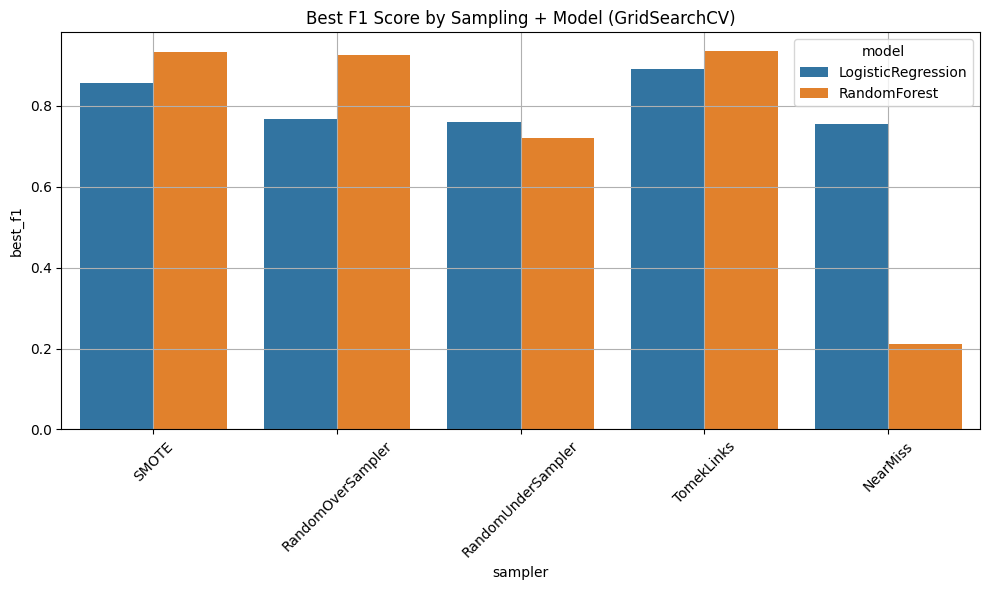

In [ ]:
# 필요한 라이브러리
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss
from sklearn.datasets import make_classification
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 생성
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1,
                           weights=[0.9, 0.1], flip_y=0, random_state=42)

print("클래스 분포:", Counter(y))

# 2. 평가 함수
def evaluate_pipeline_grid(sampler, model, model_name, param_grid):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('sampler', sampler),
        ('classifier', model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1',
        cv=5,
        n_jobs=-1,
        error_score='raise'
    )

    grid.fit(X, y)

    return {
        "model": model_name,
        "sampler": sampler.__class__.__name__,
        "best_f1": np.round(grid.best_score_, 4),
        "best_params": grid.best_params_
    }

# 3. 샘플러 + 모델 정의
samplers = [
    SMOTE(random_state=42),
    RandomOverSampler(random_state=42),
    RandomUnderSampler(random_state=42),
    TomekLinks(),
    NearMiss()
]

models_with_params = [
    (
        LogisticRegression(solver='liblinear'),
        "LogisticRegression",
        {'classifier__C': [0.1, 1, 10]}
    ),
    (
        RandomForestClassifier(random_state=42),
        "RandomForest",
        {'classifier__n_estimators': [50, 100], 'classifier__max_depth': [3, 5, None]}
    )
]

# 4. 모든 조합 실행
results = []
for sampler in samplers:
    for model, model_name, param_grid in models_with_params:
        try:
            result = evaluate_pipeline_grid(sampler, model, model_name, param_grid)
            results.append(result)
        except Exception as e:
            print(f"Error in {model_name} + {sampler.__class__.__name__}: {e}")

# 5. 결과 출력
df_result = pd.DataFrame(results)
print(df_result)

# 6. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=df_result, x='sampler', y='best_f1', hue='model')
plt.title("Best F1 Score by Sampling + Model (GridSearchCV)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


## 8. 전체통합 + confusion matrix 시각화 + classification report 출력

클래스 분포 (Train): Counter({np.int64(0): 630, np.int64(1): 70})


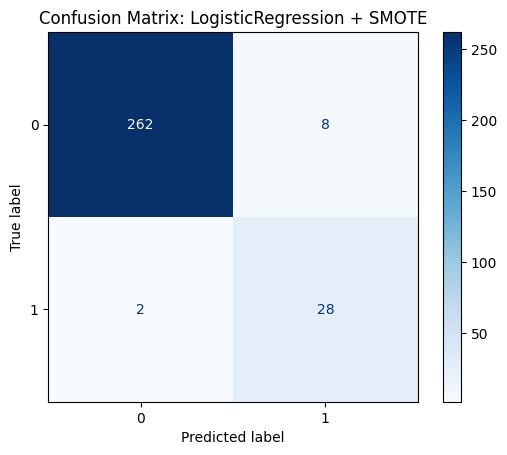

Classification Report: LogisticRegression + SMOTE
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       270
           1       0.78      0.93      0.85        30

    accuracy                           0.97       300
   macro avg       0.89      0.95      0.91       300
weighted avg       0.97      0.97      0.97       300



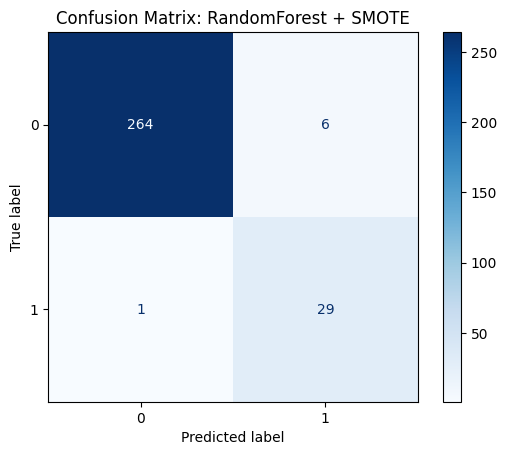

Classification Report: RandomForest + SMOTE
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       270
           1       0.83      0.97      0.89        30

    accuracy                           0.98       300
   macro avg       0.91      0.97      0.94       300
weighted avg       0.98      0.98      0.98       300



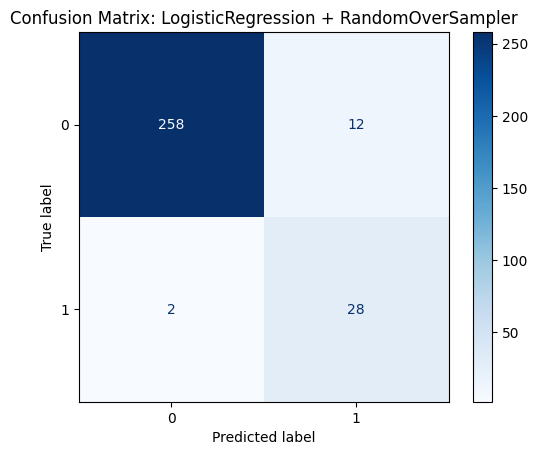

Classification Report: LogisticRegression + RandomOverSampler
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       270
           1       0.70      0.93      0.80        30

    accuracy                           0.95       300
   macro avg       0.85      0.94      0.89       300
weighted avg       0.96      0.95      0.96       300



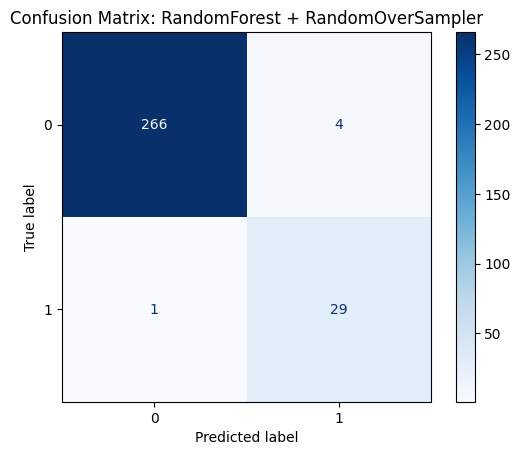

Classification Report: RandomForest + RandomOverSampler
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       270
           1       0.88      0.97      0.92        30

    accuracy                           0.98       300
   macro avg       0.94      0.98      0.96       300
weighted avg       0.98      0.98      0.98       300



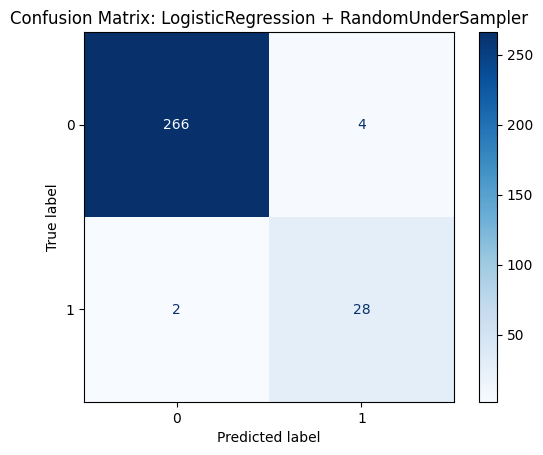

Classification Report: LogisticRegression + RandomUnderSampler
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       270
           1       0.88      0.93      0.90        30

    accuracy                           0.98       300
   macro avg       0.93      0.96      0.95       300
weighted avg       0.98      0.98      0.98       300



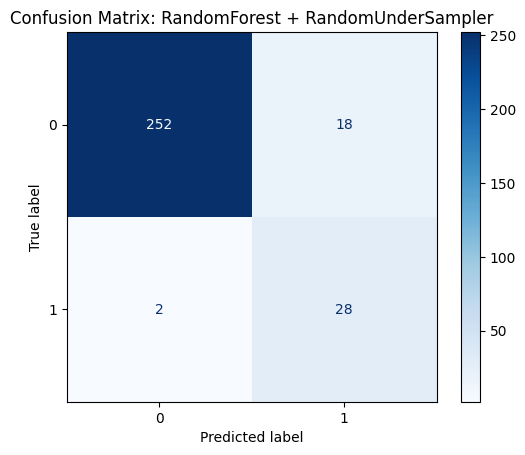

Classification Report: RandomForest + RandomUnderSampler
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       270
           1       0.61      0.93      0.74        30

    accuracy                           0.93       300
   macro avg       0.80      0.93      0.85       300
weighted avg       0.95      0.93      0.94       300



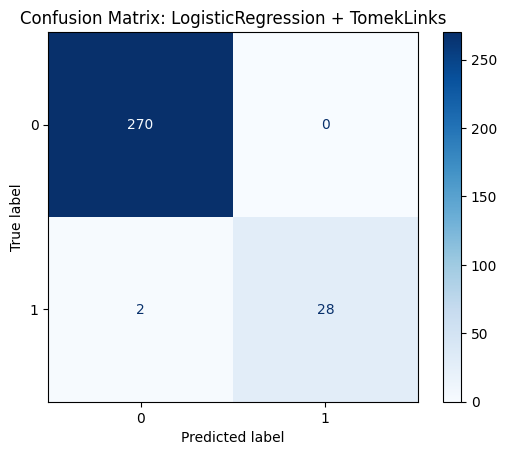

Classification Report: LogisticRegression + TomekLinks
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       270
           1       1.00      0.93      0.97        30

    accuracy                           0.99       300
   macro avg       1.00      0.97      0.98       300
weighted avg       0.99      0.99      0.99       300



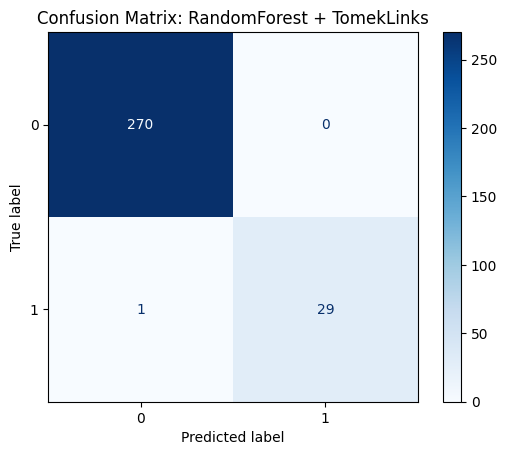

Classification Report: RandomForest + TomekLinks
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       270
           1       1.00      0.97      0.98        30

    accuracy                           1.00       300
   macro avg       1.00      0.98      0.99       300
weighted avg       1.00      1.00      1.00       300



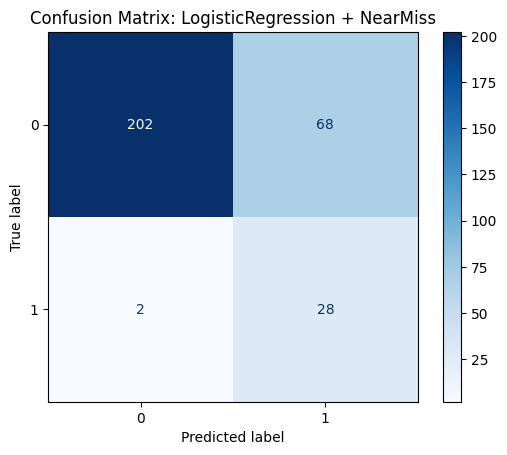

Classification Report: LogisticRegression + NearMiss
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       270
           1       0.29      0.93      0.44        30

    accuracy                           0.77       300
   macro avg       0.64      0.84      0.65       300
weighted avg       0.92      0.77      0.81       300



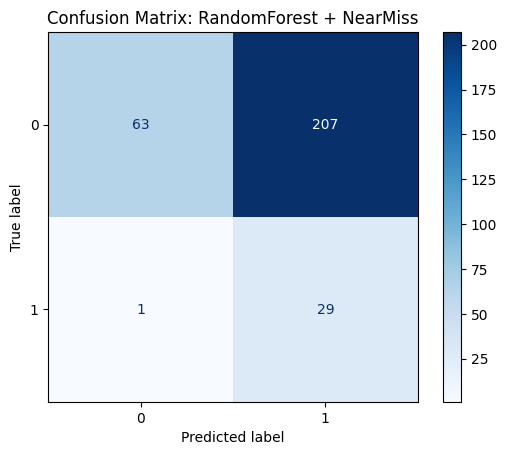

Classification Report: RandomForest + NearMiss
              precision    recall  f1-score   support

           0       0.98      0.23      0.38       270
           1       0.12      0.97      0.22        30

    accuracy                           0.31       300
   macro avg       0.55      0.60      0.30       300
weighted avg       0.90      0.31      0.36       300

                model             sampler  best_f1  \
0  LogisticRegression               SMOTE   0.7984   
1        RandomForest               SMOTE   0.8538   
2  LogisticRegression   RandomOverSampler   0.7735   
3        RandomForest   RandomOverSampler   0.9087   
4  LogisticRegression  RandomUnderSampler   0.7850   
5        RandomForest  RandomUnderSampler   0.7501   
6  LogisticRegression          TomekLinks   0.8811   
7        RandomForest          TomekLinks   0.9304   
8  LogisticRegression            NearMiss   0.5199   
9        RandomForest            NearMiss   0.3102   

                               

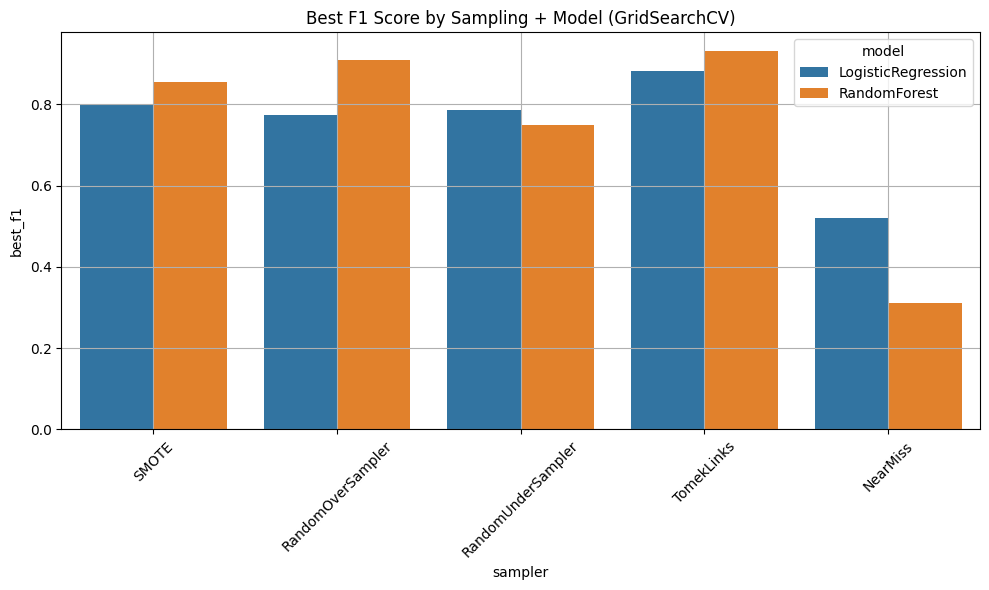

In [ ]:
# 필요한 라이브러리
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 생성 및 분할
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1,
                           weights=[0.9, 0.1], flip_y=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

print("클래스 분포 (Train):", Counter(y_train))

# 2. 평가 함수
def evaluate_pipeline_grid(sampler, model, model_name, param_grid):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('sampler', sampler),
        ('classifier', model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1',
        cv=5,
        n_jobs=-1,
        error_score='raise'
    )

    grid.fit(X_train, y_train)

    # 테스트 데이터 예측
    y_pred = grid.predict(X_test)

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid.classes_)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name} + {sampler.__class__.__name__}")
    plt.show()

    # classification report
    print(f"Classification Report: {model_name} + {sampler.__class__.__name__}")
    print(classification_report(y_test, y_pred))

    return {
        "model": model_name,
        "sampler": sampler.__class__.__name__,
        "best_f1": np.round(grid.best_score_, 4),
        "best_params": grid.best_params_
    }

# 3. 샘플러 + 모델 정의
samplers = [
    SMOTE(random_state=42),
    RandomOverSampler(random_state=42),
    RandomUnderSampler(random_state=42),
    TomekLinks(),
    NearMiss()
]

models_with_params = [
    (
        LogisticRegression(solver='liblinear'),
        "LogisticRegression",
        {'classifier__C': [0.1, 1, 10]}
    ),
    (
        RandomForestClassifier(random_state=42),
        "RandomForest",
        {'classifier__n_estimators': [50, 100], 'classifier__max_depth': [3, 5, None]}
    )
]

# 4. 모든 조합 실행
results = []
for sampler in samplers:
    for model, model_name, param_grid in models_with_params:
        try:
            result = evaluate_pipeline_grid(sampler, model, model_name, param_grid)
            results.append(result)
        except Exception as e:
            print(f"Error in {model_name} + {sampler.__class__.__name__}: {e}")

# 5. 결과 정리 및 시각화
df_result = pd.DataFrame(results)
print(df_result)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_result, x='sampler', y='best_f1', hue='model')
plt.title("Best F1 Score by Sampling + Model (GridSearchCV)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


## 9. stream 구현

Streamlit 앱 기능

| 기능                          | 설명                                      |
| --------------------------- | --------------------------------------- |
|  학습 데이터 생성                | `make_classification()`으로 불균형 데이터 생성    |
|  모델 및 샘플링 선택              | 사용자 선택 또는 전체 자동 실행                      |
|  `GridSearchCV` 기반 학습     | 하이퍼파라미터 튜닝 포함                           |
|  Confusion Matrix 시각화      | `matplotlib` + `ConfusionMatrixDisplay` |
|  Classification Report 출력 | `st.text()`로 보기 좋게 출력                   |
|  F1-score 성능 비교 바 차트      | `seaborn` 시각화                           |


Streamlit 구현 코드 (streamlit_app.py)

In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 366.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.8 MB/s eta 0:00:00


In [ ]:
%%writefile streamlit_app.py


import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss
from collections import Counter
from imblearn.pipeline import Pipeline

# -------------------
# Sidebar - 사용자 선택
# -------------------
st.sidebar.title("설정")
selected_model = st.sidebar.selectbox("모델 선택", ["LogisticRegression", "RandomForest"])
selected_sampler = st.sidebar.selectbox("샘플링 기법 선택", ["SMOTE", "RandomOverSampler", "RandomUnderSampler", "TomekLinks", "NearMiss"])

# -------------------
# 데이터 생성
# -------------------
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1,
                           weights=[0.9, 0.1], flip_y=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

st.title("불균형 데이터 분류 - Streamlit 앱")
st.write("Train 클래스 분포:", {int(k): v for k, v in Counter(y_train).items()})

# -------------------
# 샘플러 및 모델 정의
# -------------------
sampler_dict = {
    "SMOTE": SMOTE(random_state=42),
    "RandomOverSampler": RandomOverSampler(random_state=42),
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "TomekLinks": TomekLinks(),
    "NearMiss": NearMiss()
}
model_dict = {
    "LogisticRegression": (LogisticRegression(solver='liblinear'), {'classifier__C': [0.1, 1, 10]}),
    "RandomForest": (RandomForestClassifier(random_state=42), {'classifier__n_estimators': [50, 100], 'classifier__max_depth': [3, 5, None]})
}

sampler = sampler_dict[selected_sampler]
model, param_grid = model_dict[selected_model]

# -------------------
# 샘플링 전 데이터 시각화
# -------------------
st.subheader("샘플링 전 데이터 분포")
fig1, ax1 = plt.subplots()
scatter = ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolor='k', alpha=0.7)
ax1.set_title("Before Sampling")
st.pyplot(fig1)

# -------------------
# 데이터 타입 보정 (Pandas → ndarray로 변환)
# -------------------
X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.int64).ravel()

# -------------------
# 샘플링 적용
# -------------------
X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
st.write("Resampled 클래스 분포:", {int(k): v for k, v in Counter(y_resampled).items()})

# -------------------
# 샘플링 후 데이터 시각화
# -------------------
st.subheader("샘플링 후 데이터 분포")
fig2, ax2 = plt.subplots()
scatter = ax2.scatter(X_resampled[:, 0], X_resampled[:, 1], c=y_resampled, cmap='coolwarm', edgecolor='k', alpha=0.7)
ax2.set_title("After Sampling")
st.pyplot(fig2)

# -------------------
# 모델 학습 및 평가
# -------------------
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', model)
])

grid = GridSearchCV(pipe, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(X_resampled, y_resampled)
y_pred = grid.predict(X_test)

# -------------------
# 결과 출력
# -------------------
st.subheader("Best F1 Score")
st.metric("F1 Score", f"{grid.best_score_:.4f}")
st.write("Best Parameters:", grid.best_params_)

st.subheader("Classification Report")
st.text(classification_report(y_test, y_pred))

st.subheader("Confusion Matrix")
fig3, ax3 = plt.subplots()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=grid.classes_)
disp.plot(ax=ax3, cmap='Blues')
st.pyplot(fig3)


Writing streamlit_app.py


In [ ]:
%%writefile requirements.txt
streamlit>=1.35.0
imbalanced-learn>=0.11.0
scikit-learn>=1.3.0
matplotlib>=3.7.0
pandas>=2.1.0
numpy>=1.23.0
seaborn>=0.12.0

Writing requirements.txt


In [ ]:
!pip freeze > requirements.txt

In [ ]:
# from google.colab import files
# files.download('requirements.txt')

In [ ]:
# anaconda에서 requirements.txt 생성
# pip list --format=freeze > requirements.txt

실행방법(bash)

In [ ]:
# 파일 저장
$ nano streamlit_app.py  # 또는 streamlit_app.py로 저장

# 실행
$ streamlit run streamlit_app.py


SyntaxError: invalid syntax (ipython-input-3475741922.py, line 2)